In [12]:
import pandas as pd
import numpy as np


In [13]:
df = pd.read_csv(r'C:/Users/DELL/Desktop/Hotel_Insights_Pro/data/Hotels.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [14]:
# الأعمدة الرقمية
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# الأعمدة النصية
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [15]:
df.drop_duplicates(inplace=True)
df.shape


(119390, 36)

In [16]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [17]:
# إزالة الأسعار السالبة
if 'adr' in df.columns:
    df = df[df['adr'] >= 0]

# إزالة قيم الأطفال السالبة
if 'children' in df.columns:
    df = df[df['children'] >= 0]


In [18]:
df.to_csv(r'C:/Users/DELL/Desktop/Hotel_Insights_Pro/data/Hotels_cleaned.csv', index=False)


In [19]:
df.describe(include='all')


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119389,119389.000000,119389.000000,119389.000000,119389,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,...,119389,119389.000000,119389.000000,119389.000000,119389,119389,119389,119389,119389,119389
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,4,NaN,NaN,NaN,3,926,81502,115888,119389,9000
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,Transient,NaN,NaN,NaN,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,669-792-1661,************4923
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,89613,NaN,NaN,NaN,75165,1461,48,6,1,28
mean,NaN,0.370419,104.010654,2016.156547,NaN,27.165317,15.798332,0.927573,2.500272,1.856402,...,NaN,101.832028,0.062518,0.571368,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.482919,106.863220,0.707475,NaN,13.605105,8.780811,0.998578,1.908267,0.579263,...,NaN,50.535032,0.245292,0.792800,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,69.290000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,94.590000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,126.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
df['is_canceled'].value_counts()


is_canceled
0    75165
1    44224
Name: count, dtype: int64

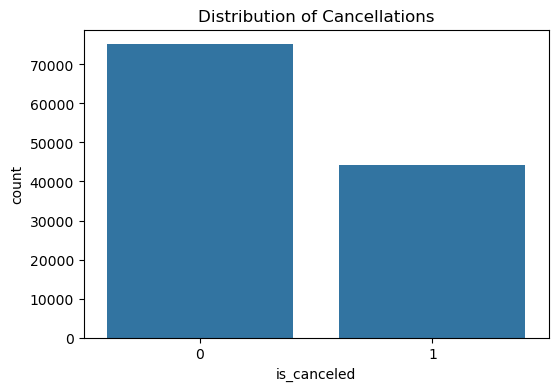

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_canceled')
plt.title('Distribution of Cancellations')
plt.savefig("images/Distribution of Cancellations.png", dpi=300, bbox_inches='tight')
plt.show()


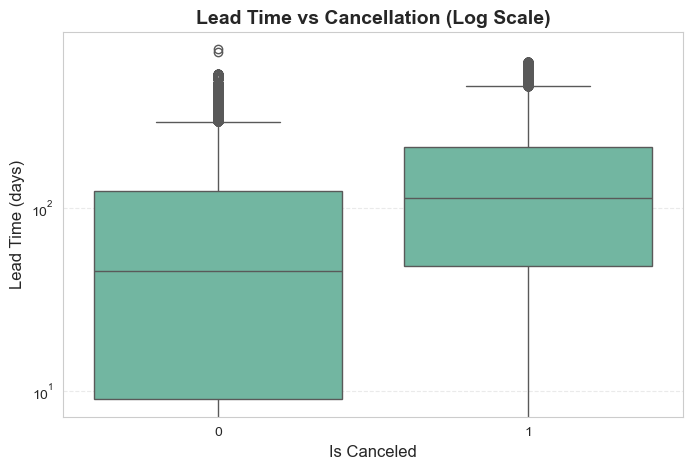

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("Set2")

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.title('Lead Time vs Cancellation (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Is Canceled', fontsize=12)
plt.ylabel('Lead Time (days)', fontsize=12)

plt.savefig("images/Lead Time vs Cancellation (Improved).png", dpi=300, bbox_inches='tight')
plt.show()



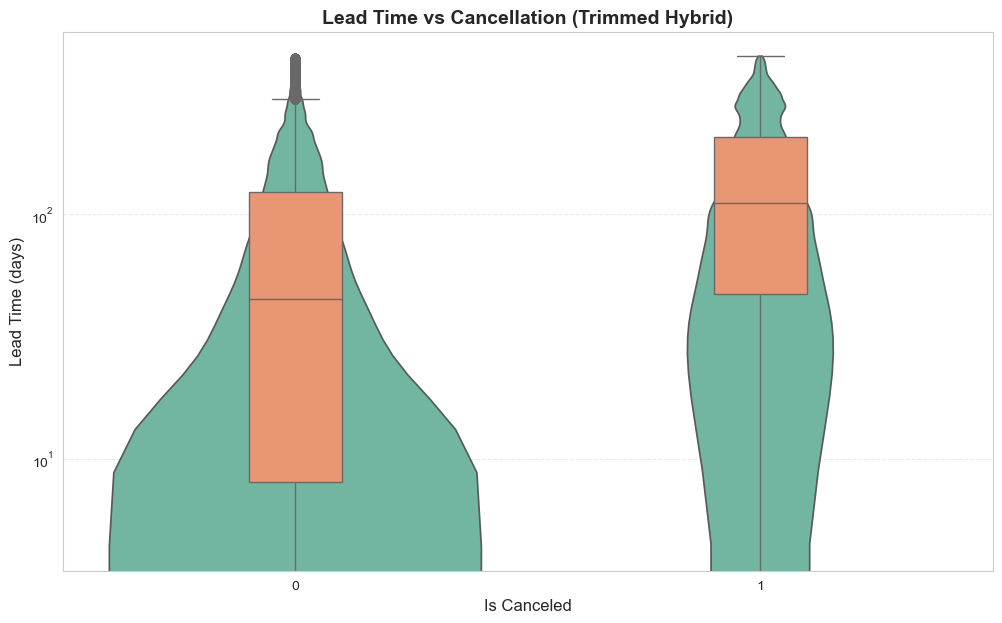

In [26]:
df_trim = df[df['lead_time'] < df['lead_time'].quantile(0.99)]

plt.figure(figsize=(12,7))
sns.violinplot(data=df_trim, x='is_canceled', y='lead_time', inner=None, cut=0)
sns.boxplot(data=df_trim, x='is_canceled', y='lead_time', width=0.2)

plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.title('Lead Time vs Cancellation (Trimmed Hybrid)', fontsize=14, fontweight='bold')
plt.xlabel('Is Canceled', fontsize=12)
plt.ylabel('Lead Time (days)', fontsize=12)

plt.savefig("images/Lead Time vs Cancellation (Trimmed Hybrid).png", dpi=300, bbox_inches='tight')
plt.show()



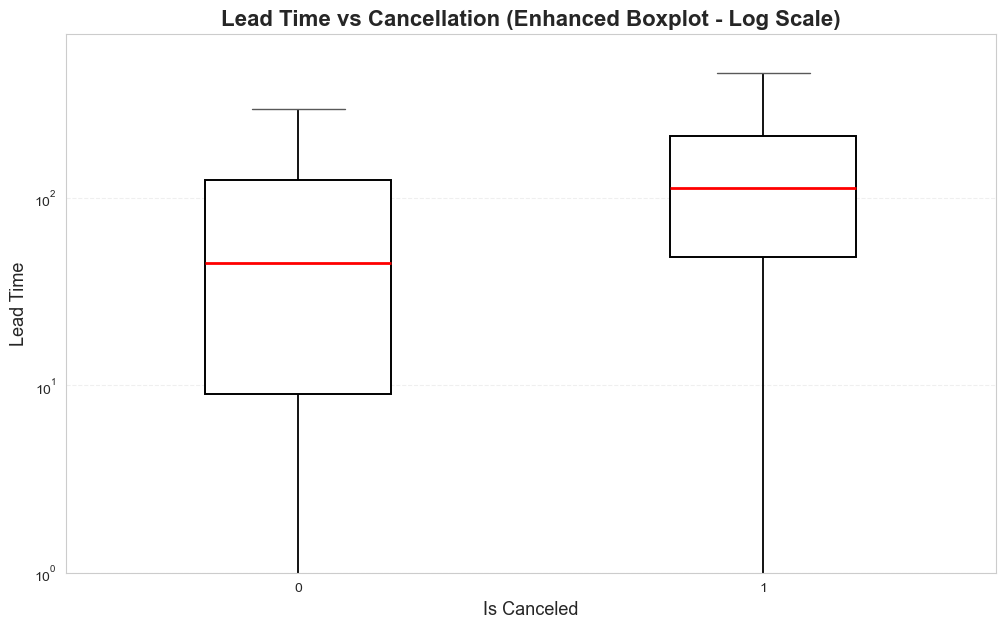

In [27]:
plt.figure(figsize=(12,7))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='lead_time',
    width=0.4,
    showcaps=True,
    boxprops={'facecolor':'white', 'edgecolor':'black', 'linewidth':1.4},
    whiskerprops={'color':'black', 'linewidth':1.3},
    medianprops={'color':'red', 'linewidth':2},
    showfliers=False
)

plt.yscale('log')
plt.ylim(1, df['lead_time'].max() + 10)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Lead Time vs Cancellation (Enhanced Boxplot - Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Is Canceled', fontsize=13)
plt.ylabel('Lead Time', fontsize=13)

plt.savefig("images/Lead Time vs Cancellation (Boxplot Only).png", dpi=300, bbox_inches='tight')
plt.show()


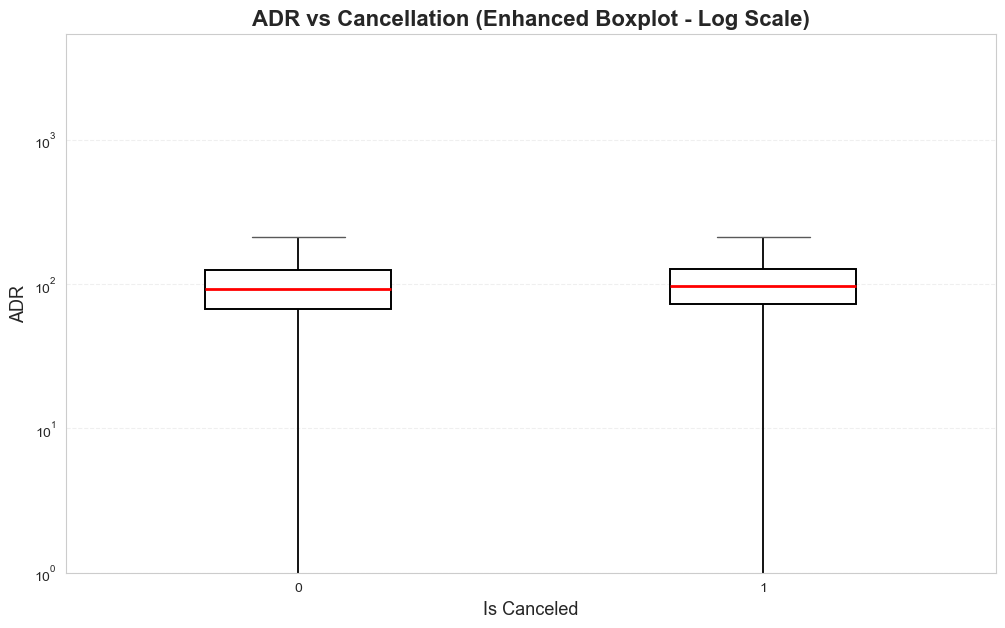

In [28]:
plt.figure(figsize=(12,7))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='adr',
    width=0.4,
    showcaps=True,
    boxprops={'facecolor':'white', 'edgecolor':'black', 'linewidth':1.4},
    whiskerprops={'color':'black', 'linewidth':1.3},
    medianprops={'color':'red', 'linewidth':2},
    showfliers=False
)

plt.yscale('log')
plt.ylim(1, df['adr'].max() + 10)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('ADR vs Cancellation (Enhanced Boxplot - Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Is Canceled', fontsize=13)
plt.ylabel('ADR', fontsize=13)

plt.savefig("images/ADR vs Cancellation (Boxplot Only).png", dpi=300, bbox_inches='tight')
plt.show()


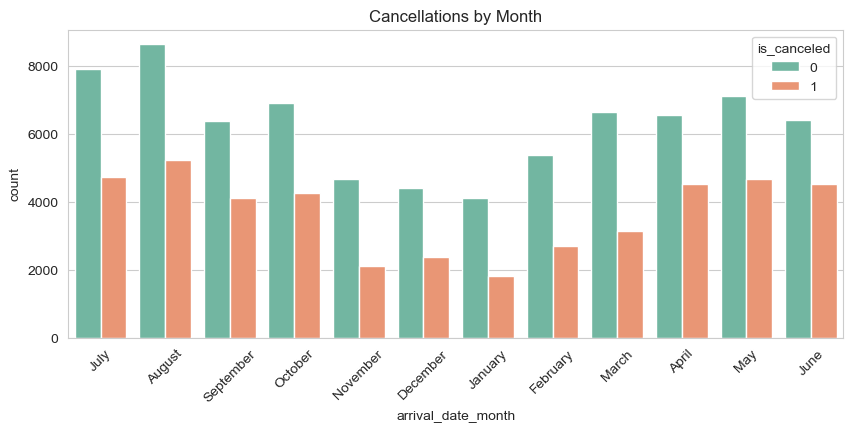

In [29]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='arrival_date_month', hue='is_canceled')
plt.title('Cancellations by Month')
plt.xticks(rotation=45)
plt.savefig("images/Cancellations by Month.png", dpi=300, bbox_inches='tight')
plt.show()


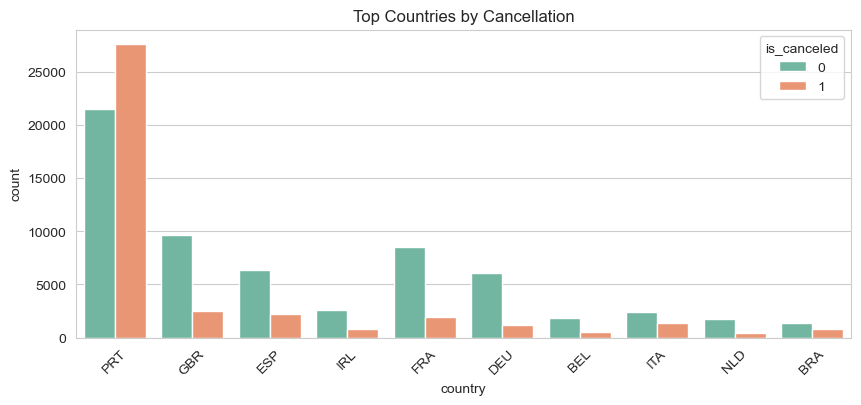

In [30]:
top_countries = df['country'].value_counts().head(10).index

plt.figure(figsize=(10,4))
sns.countplot(data=df[df['country'].isin(top_countries)], 
              x='country', hue='is_canceled')
plt.title('Top Countries by Cancellation')
plt.xticks(rotation=45)
plt.savefig("images/Top Countries by Cancellation.png", dpi=300, bbox_inches='tight')
plt.show()


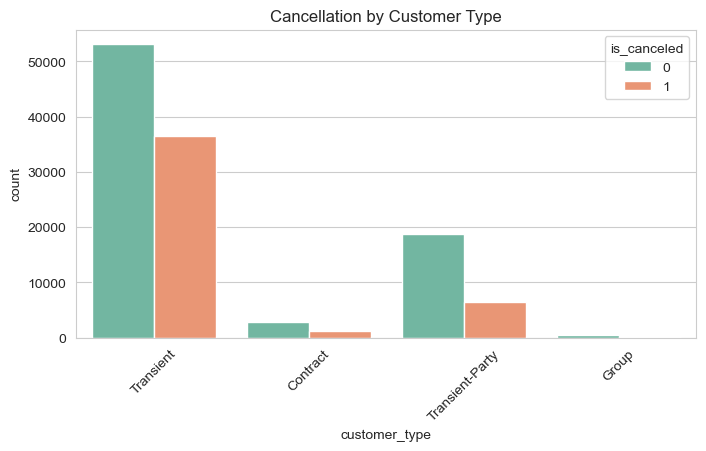

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='customer_type', hue='is_canceled')
plt.title('Cancellation by Customer Type')
plt.xticks(rotation=45)
plt.savefig("images/Cancellation by Customer Type.png", dpi=300, bbox_inches='tight')
plt.show()


In [32]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']



In [33]:
df['total_nights'].describe()


count    119389.000000
mean          3.427845
std           2.557379
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          69.000000
Name: total_nights, dtype: float64

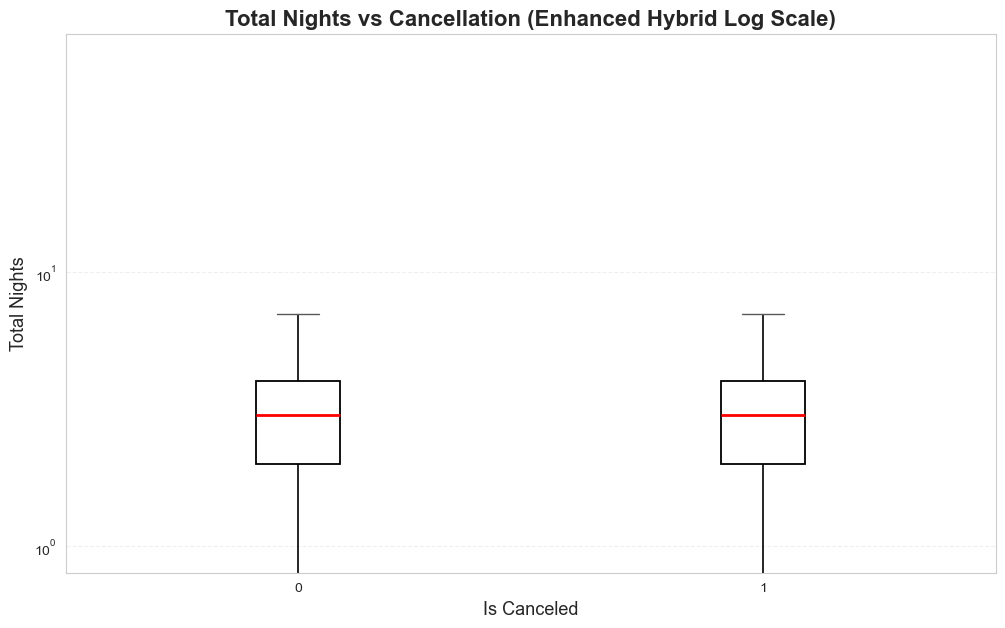

In [34]:
plt.figure(figsize=(12,7))

# Boxplot محسّن فوق الـ violin
sns.boxplot(
    data=df,
    x='is_canceled',
    y='total_nights',
    width=0.18,
    showcaps=True,
    boxprops={'facecolor':'white', 'edgecolor':'black', 'linewidth':1.3},
    whiskerprops={'color':'black', 'linewidth':1.2},
    medianprops={'color':'red', 'linewidth':2},
    showfliers=False       # إخفاء النقاط الشاذة لأنها تشوّه الشكل
)

# مقياس لوغاريتمي
plt.yscale('log')
plt.ylim(0.8, df['total_nights'].max() + 5)

# شبكة خفيفة
plt.grid(axis='y', linestyle='--', alpha=0.3)

# عناوين
plt.title('Total Nights vs Cancellation (Enhanced Hybrid Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Is Canceled', fontsize=13)
plt.ylabel('Total Nights', fontsize=13)

# حفظ الصورة
plt.savefig("images/Total Nights vs Cancellation (Enhanced Hybrid Final).png", dpi=300, bbox_inches='tight')
plt.show()


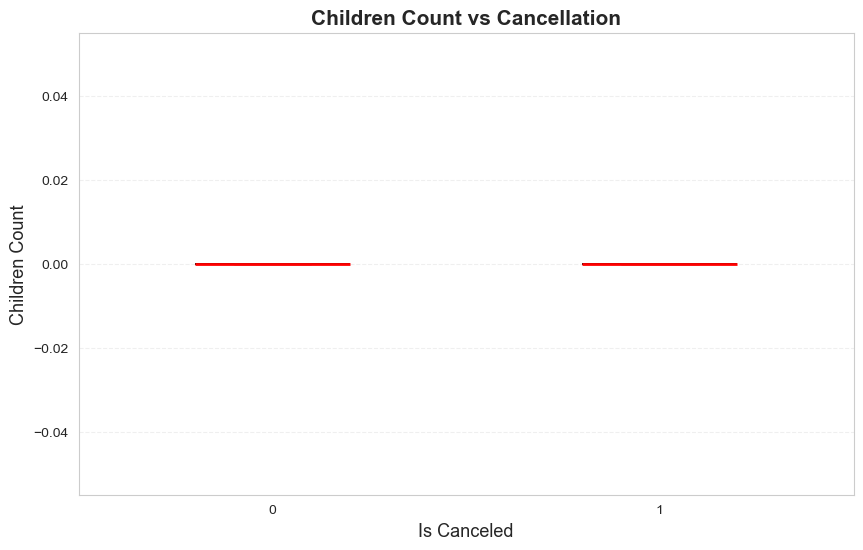

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='children',
    width=0.4,
    showcaps=True,
    boxprops={'facecolor':'white', 'edgecolor':'black', 'linewidth':1.3},
    whiskerprops={'color':'black', 'linewidth':1.2},
    medianprops={'color':'red', 'linewidth':2},
    showfliers=False
)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Children Count vs Cancellation', fontsize=15, fontweight='bold')
plt.xlabel('Is Canceled', fontsize=13)
plt.ylabel('Children Count', fontsize=13)

plt.savefig("images/Children Count vs Cancellation (Enhanced).png", dpi=300, bbox_inches='tight')
plt.show()


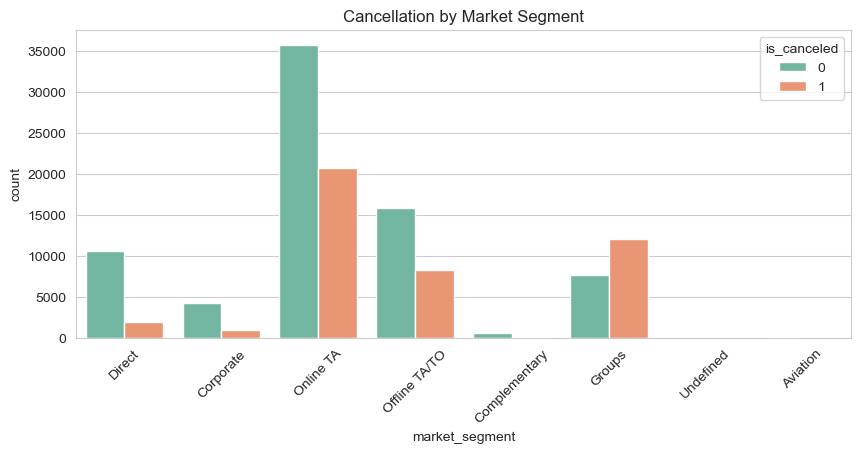

In [36]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='market_segment', hue='is_canceled')
plt.title('Cancellation by Market Segment')
plt.xticks(rotation=45)
plt.savefig("images/Cancellation by Market Segment.png", dpi=300, bbox_inches='tight')
plt.show()


In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df_model = df.copy()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

import pandas as pd
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance.head(15)


,feature,importance
29,reservation_status,0.703055
21,deposit_type,0.075556
12,country,0.037043
1,lead_time,0.031680
28,total_of_special_requests,0.022125
30,reservation_status_date,0.020959
13,market_segment,0.017355
16,previous_cancellations,0.015002
22,agent,0.010029
27,required_car_parking_spaces,0.007878


In [38]:
df_model = df.copy()

# Remove leakage columns
leakage_cols = [
    'reservation_status',
    'reservation_status_date'
]

df_model = df_model.drop(columns=leakage_cols, errors='ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encode categorical columns
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8878465533126727

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91     14927
           1       0.89      0.80      0.84      8951

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.88     23878
weighted avg       0.89      0.89      0.89     23878


Confusion Matrix:
 [[14081   846]
 [ 1832  7119]]


In [39]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_




In [ ]:
import os

print(os.listdir())


In [ ]:
import os

for root, dirs, files in os.walk("C:\\", topdown=True):
    if "hotel_cancellation_model.pkl" in files:
        print(os.path.join(root, "hotel_cancellation_model.pkl"))
        break


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(r'C:/Users/DELL/Desktop/Hotel_Insights_Pro/data/Hotels.csv')
df.info()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Encode categorical variables
for col in df_model.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

# Split data
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)


In [ ]:
import joblib
joblib.dump(model, 'hotel_cancellation_model.pkl')

print("Model saved successfully!")


In [ ]:
loaded_model = joblib.load('hotel_cancellation_model.pkl')
print("Model loaded successfully!")


In [ ]:
sample = X_test.iloc[0:1]   # مثال: أول صف من بيانات الاختبار
prediction = loaded_model.predict(sample)

print("Prediction:", prediction)


In [ ]:
import os

# إنشاء مجلد images إذا لم يكن موجودًا
os.makedirs("images", exist_ok=True)


In [ ]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            print(os.path.join(root, f))


In [ ]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=18, fontweight='bold')
plt.savefig("images/Correlation Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
